# Aquaculture Pond Identification — 9th place solution

**Private score 0.947 · Public score 0.942367202**

Full write-up: [`DOCUMENTATION.md`](DOCUMENTATION.md).

---

## The problem in three numbers

| | |
|---|---|
| `Train.csv` | 1 821 rows, **12 full months** of observations, 40.36 % ponds |
| `Test.csv`  | 1 030 rows, **4 to 6 consecutive months only** |
| metric | `0.6 × F1 + 0.4 × ROC-AUC`, binary column thresholded at **0.5** (imposed by the rules) |

Each row is one 10 m × 10 m patch described by 12 bands × 12 monthly composites:
10 optical (Sentinel-2) and 2 radar (Sentinel-1), with `-9999` marking missing
data.

## What actually makes it hard

Two things, and the whole solution is organised around them.

**1. The training rows do not look like the test rows.** Training patches are
seen for 12 months, test patches for a 4–6 month window. The test set is in fact
*exactly* the 24 possible consecutive windows. Descriptors computed over 12
months simply do not exist at inference time. Section 2 shows this.

**2. Train and test are different acquisitions.** A discriminator trained to tell
the two apart reaches **AUC 0.98** even after identical masking, keying on
absolute radiometry. Classical importance weighting is arithmetically impossible
here — the density-ratio weights collapse to an effective sample size of 10 rows
out of 1 821. Section 8 is the answer to this one.

Everything below is either standard tabular practice or a direct answer to one of
those two facts.

## 1. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RNG_SEED = 42
SEEDS = [42, 123, 456, 789, 1337, 2024, 7, 99]
BANDS = ['blue', 'green', 'red', 'nir', 'nira', 'swir1', 'swir2', 're1', 're2', 're3', 'VH', 'VV']
OPT = ['blue', 'green', 'red', 'nir', 'nira', 'swir1', 'swir2', 're1', 're2', 're3']
SAR = ['VH', 'VV']

print("Loading data...")
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

TRAIN_PRIOR = train['label'].mean()
print(f"Train prior (fraction positive): {TRAIN_PRIOR:.4f}")

Loading data...
Train shape: (1821, 146), Test shape: (1030, 145)
Train prior (fraction positive): 0.4036


In [2]:
import os
os.makedirs('cache', exist_ok=True)

---

## 2. Exploring the data — the two facts that shape everything

The first thing worth plotting is not a feature distribution — it is **the shape
of the observation itself**, because that is where the difficulty lives.

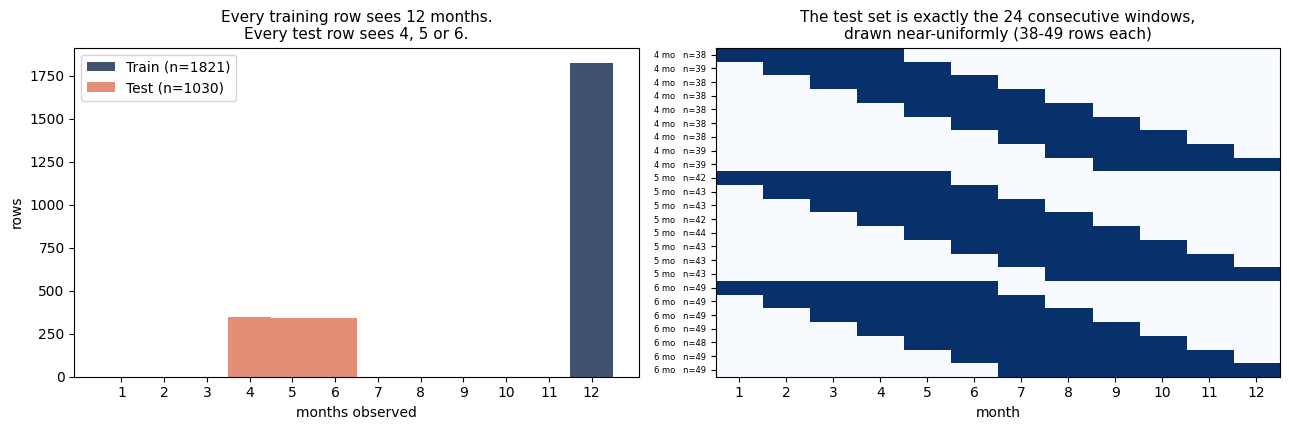

In [3]:
import matplotlib.pyplot as plt

# notebook-only helper; the pipeline recomputes these masks in section 3
def sensor_masks(df):
    opt = np.zeros((len(df), 12), bool)
    sar = np.zeros((len(df), 12), bool)
    for m in range(1, 13):
        ms = f'{m:02d}'
        sar[:, m-1] = (df[f'VH_{ms}'].values != -9999) & (df[f'VV_{ms}'].values != -9999)
        opt[:, m-1] = ((df[f'blue_{ms}'].values != -9999) & (df[f'green_{ms}'].values != -9999)
                       & (df[f'red_{ms}'].values != -9999) & (df[f'nir_{ms}'].values != -9999)
                       & (df[f'swir1_{ms}'].values != -9999))
    return opt, sar

C_POS, C_NEG, C_TR, C_TE = '#2d6a4f', '#b23a48', '#1d3557', '#e07a5f'
tr_opt, tr_sar = sensor_masks(train)
te_opt_eda, te_sar_eda = sensor_masks(test)
tr_any, te_any = tr_opt | tr_sar, te_opt_eda | te_sar_eda

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
bins = np.arange(0.5, 13.5)
ax[0].hist(tr_any.sum(1), bins=bins, color=C_TR, alpha=.85, label=f'Train (n={len(train)})')
ax[0].hist(te_any.sum(1), bins=bins, color=C_TE, alpha=.85, label=f'Test (n={len(test)})')
ax[0].set_xlabel('months observed'); ax[0].set_ylabel('rows'); ax[0].set_xticks(range(1, 13))
ax[0].set_title('Every training row sees 12 months.\nEvery test row sees 4, 5 or 6.', fontsize=11)
ax[0].legend()

pat = {}
for row in te_any:
    k = tuple(np.where(row)[0]); pat[k] = pat.get(k, 0) + 1
order = sorted(pat, key=lambda k: (len(k), k[0]))
M = np.zeros((len(order), 12))
for i, k in enumerate(order):
    M[i, list(k)] = 1
ax[1].imshow(M, aspect='auto', cmap='Blues', interpolation='nearest')
ax[1].set_yticks(range(len(order)))
ax[1].set_yticklabels([f'{len(k)} mo   n={pat[k]}' for k in order], fontsize=6)
ax[1].set_xticks(range(12)); ax[1].set_xticklabels(range(1, 13)); ax[1].set_xlabel('month')
ax[1].set_title(f'The test set is exactly the {len(order)} consecutive windows,\n'
                f'drawn near-uniformly ({min(pat.values())}-{max(pat.values())} rows each)',
                fontsize=11)
plt.tight_layout(); plt.show()

**That right-hand panel is the single most useful plot in this notebook.** The
test set is not a random subsample of months — it is a clean sweep of all 24
consecutive windows, 9 of length 4, 8 of length 5, 7 of length 6, each drawn 38
to 49 times. Knowing this is what makes the masking simulation in section 3
possible, and what makes it faithful rather than approximate.

Next: missingness is not uniform across the two sensors.

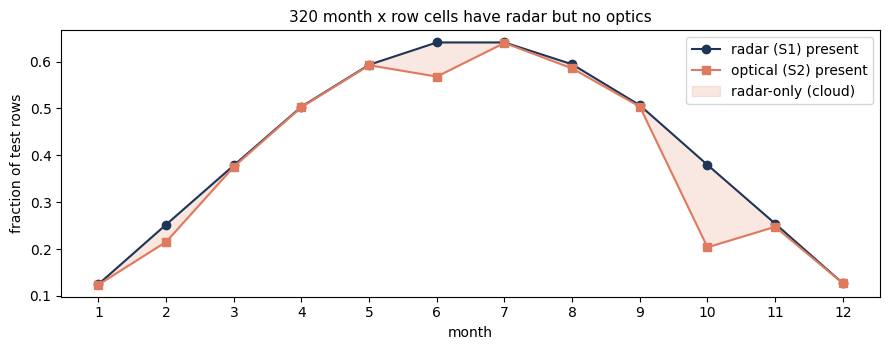

dual-sensor cells : 4827
radar-only cells  : 320


In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
mo = np.arange(1, 13)
ax.plot(mo, te_sar_eda.mean(0), 'o-', color=C_TR, label='radar (S1) present')
ax.plot(mo, te_opt_eda.mean(0), 's-', color=C_TE, label='optical (S2) present')
ax.fill_between(mo, te_opt_eda.mean(0), te_sar_eda.mean(0),
                where=te_sar_eda.mean(0) >= te_opt_eda.mean(0),
                color=C_TE, alpha=.18, label='radar-only (cloud)')
n_only = int((te_sar_eda & ~te_opt_eda).sum())
ax.set_xticks(mo); ax.set_xlabel('month'); ax.set_ylabel('fraction of test rows')
ax.set_title(f'{n_only} month x row cells have radar but no optics', fontsize=11)
ax.legend(); plt.tight_layout(); plt.show()
print(f'dual-sensor cells : {int((te_opt_eda & te_sar_eda).sum())}')
print(f'radar-only cells  : {n_only}')

**320 cells carry radar without optics.** Masking whole months would throw that
radar away *and* would mean the model never trains on the case. This is why every
index series in section 4 carries its own sensor's validity mask rather than a
shared one.

Now the signal itself — what actually separates a pond from anything else.

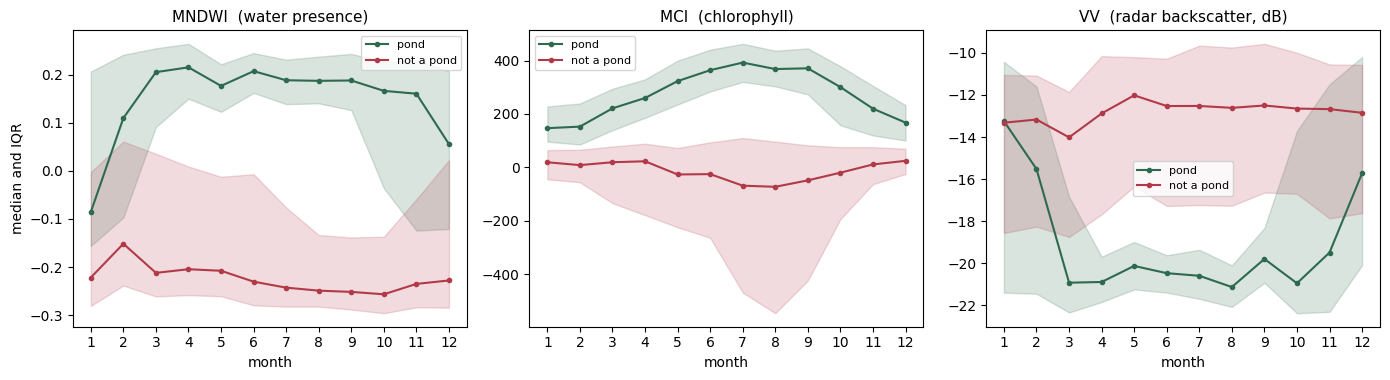

univariate AUC of the temporal median:
   MNDWI  (water presence)        0.8906
   MCI  (chlorophyll)             0.9551
   VV  (radar backscatter, dB)    0.7648


In [5]:
a_eda = {b: np.stack([train[f'{b}_{m:02d}'].values for m in range(1, 13)], 1).astype(float)
         for b in BANDS}
for b in a_eda:
    a_eda[b][a_eda[b] == -9999] = np.nan

with np.errstate(all='ignore'):
    eda_series = {
        'MNDWI  (water presence)': (a_eda['green'] - a_eda['swir1']) / (a_eda['green'] + a_eda['swir1'] + 1e-8),
        'MCI  (chlorophyll)': a_eda['re1'] - a_eda['red'] - 0.5333 * (a_eda['re2'] - a_eda['red']),
        'VV  (radar backscatter, dB)': a_eda['VV'],
    }

lab_eda = train['label'].values
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
for i, (name, S) in enumerate(eda_series.items()):
    for lab, col, tag in ((1, C_POS, 'pond'), (0, C_NEG, 'not a pond')):
        sub = S[lab_eda == lab]
        ax[i].plot(mo, np.nanmedian(sub, 0), '-o', color=col, ms=3, label=tag)
        ax[i].fill_between(mo, np.nanpercentile(sub, 25, axis=0),
                           np.nanpercentile(sub, 75, axis=0), color=col, alpha=.18)
    ax[i].set_title(name, fontsize=11); ax[i].set_xticks(mo); ax[i].set_xlabel('month')
    ax[i].legend(fontsize=8)
ax[0].set_ylabel('median and IQR')
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_auc_score as _auc
print('univariate AUC of the temporal median:')
for name, S in eda_series.items():
    v = np.nanmedian(S, 1); ok = ~np.isnan(v)
    print(f'   {name:30s} {max(_auc(lab_eda[ok], v[ok]), 1 - _auc(lab_eda[ok], v[ok])):.4f}')

**An early clue worth holding on to.** The intuitive discriminator is water —
MNDWI — and it does separate the classes (univariate AUC 0.89). But **MCI, a
red-edge chlorophyll index, separates them better (0.96)**, on its own, with no
model at all.

That is not what one expects from a "find the water" task, and section 9 will
show with SHAP that the trained model reaches the same conclusion. Aquaculture
ponds are fed and fertilised, so they are eutrophic; the question the data
answers best is not *is there water* but *what kind of water*.

---

## 3. Challenge 1 — making the training set look like the test set

This is the first of the two mechanisms that matter, and section 2 is what makes
it possible: because the test windows are known exactly, they can be replayed
onto the training set rather than approximated.

For every test row we keep **two** boolean vectors of length 12 — optics present,
radar present — and `mask_train_like_test` gives each training row one randomly
drawn *real* test pattern, blanking the corresponding columns per sensor.

**Why one sampled window per row rather than all 24?** Generating every window
explicitly gives a 43 704-row training set and is the obvious move. It is also
wrong here: the trees memorise 24 near-identical copies of each pond. Two
independent implementations of that idea scored **0.910** and **0.887** against
**0.94** for this approach. Sampling one real pattern per row, with 8 seeds
averaged at the end, buys the window-invariance without the memorisation.

In [6]:
# ===================================================================
# 1. Motifs d'observation reels, PAR CAPTEUR
# ===================================================================
print("Extracting test missingness patterns (per sensor)...")
test_opt = np.zeros((len(test), 12), dtype=bool)
test_sar = np.zeros((len(test), 12), dtype=bool)
for m in range(1, 13):
    ms = f'{m:02d}'
    test_sar[:, m - 1] = (test[f'VH_{ms}'].values != -9999) & (test[f'VV_{ms}'].values != -9999)
    test_opt[:, m - 1] = (test[f'blue_{ms}'].values != -9999) & (test[f'green_{ms}'].values != -9999) & \
                         (test[f'red_{ms}'].values != -9999) & (test[f'nir_{ms}'].values != -9999) & \
                         (test[f'swir1_{ms}'].values != -9999)
n_both = int((test_opt & test_sar).sum())
n_s1only = int((test_sar & ~test_opt).sum())
print(f"  {n_both} cellules bi-capteur, {n_s1only} SAR-only "
      f"(v5 jetait ces {n_s1only} cellules radar)")

train_nan = train.replace(-9999, np.nan)


def mask_train_like_test(seed):
    """Une ligne de test tiree au hasard donne son motif d'observation, capteur
    par capteur : l'optique et le radar peuvent manquer independamment."""
    rng = random.Random(seed)
    tm = train_nan.copy()
    idx = [rng.randrange(len(test)) for _ in range(len(tm))]
    o = test_opt[idx]
    s = test_sar[idx]
    for m in range(1, 13):
        ms = f'{m:02d}'
        rows = np.where(~o[:, m - 1])[0]
        if len(rows):
            tm.loc[tm.index[rows], [f'{b}_{ms}' for b in OPT]] = np.nan
        rows = np.where(~s[:, m - 1])[0]
        if len(rows):
            tm.loc[tm.index[rows], [f'{b}_{ms}' for b in SAR]] = np.nan
    return tm

Extracting test missingness patterns (per sensor)...
  4827 cellules bi-capteur, 320 SAR-only (v5 jetait ces 320 cellules radar)


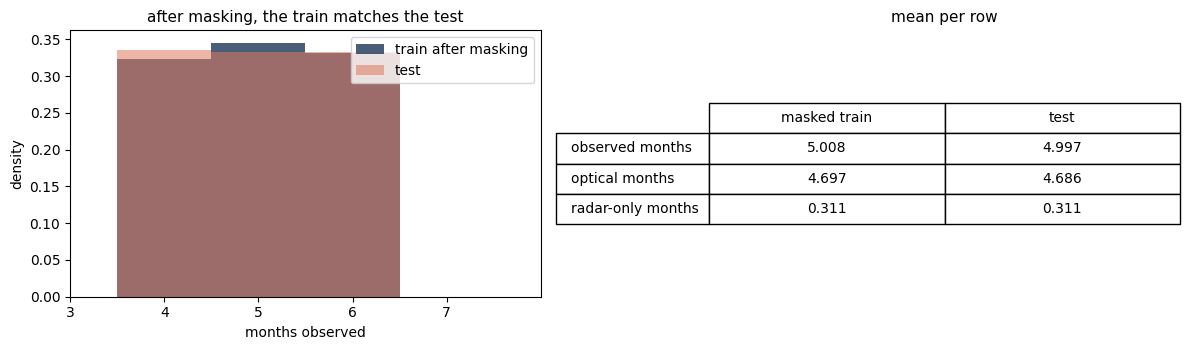

                   masked train   test
observed months           5.008  4.997
optical months            4.697  4.686
radar-only months         0.311  0.311


In [7]:
tm_demo = mask_train_like_test(42)
tm_opt, tm_sar = sensor_masks(tm_demo.fillna(-9999))
tm_any = tm_opt | tm_sar

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(tm_any.sum(1), bins=bins, color=C_TR, alpha=.8, density=True, label='train after masking')
ax[0].hist(te_any.sum(1), bins=bins, color=C_TE, alpha=.55, density=True, label='test')
ax[0].set_xlim(3, 8); ax[0].set_xticks(range(3, 8))
ax[0].set_xlabel('months observed'); ax[0].set_ylabel('density'); ax[0].legend()
ax[0].set_title('after masking, the train matches the test', fontsize=11)

stats = pd.DataFrame({
    'masked train': [tm_any.sum(1).mean(), tm_opt.sum(1).mean(), (tm_sar & ~tm_opt).sum(1).mean()],
    'test':         [te_any.sum(1).mean(), te_opt_eda.sum(1).mean(),
                     (te_sar_eda & ~te_opt_eda).sum(1).mean()]},
    index=['observed months', 'optical months', 'radar-only months'])
ax[1].axis('off')
ax[1].table(cellText=np.round(stats.values, 3), rowLabels=stats.index,
            colLabels=stats.columns, loc='center', cellLoc='center').scale(1, 1.9)
ax[1].set_title('mean per row', fontsize=11)
plt.tight_layout(); plt.show()
print(stats.round(3).to_string())

Agreement to within 0.01 months on all three, including the radar-only rate
(0.311 against 0.311). The simulation is faithful, not approximate.

---

## 4. Feature extraction — 316 temporal descriptors

Sixteen spectral and radar index series computed month by month, **each carrying
its own sensor's validity mask**: optical indices only where the optics are
present, radar indices only where the radar is. A radar-only month therefore
still contributes its radar descriptors.

* optical — `mndwi, ndvi, evi, sabi, cdom, mci, twobda, ndsi, awei, nira_ndvi,
  water_product, awei_mndwi_diff`
* radar — `sar, sdwi, vh_vv, rvi, vh_vv_ratio`

Per series, over the observed window only: 7 percentiles, min, max, range,
standard deviation, IQR, fraction positive, skewness, kurtosis, coefficient of
variation. Then gradients on six series, lag-1 autocorrelation on four, six
cross-series correlations, water-frequency and water-consistency scores, and
eight descriptors of the observation structure itself.

Two details that are easy to get wrong:

* **Every moment uses its own series' valid-month count**, never a global one — a
  direct consequence of decoupling the sensor masks. A shared count would
  silently corrupt skewness and kurtosis on radar-only months.
* **No normalisation.** Gradient-boosted trees are invariant to monotone
  per-feature transforms, so scaling would be inert. The robustness comes from
  the indices themselves being normalised differences and ratios.

The 316-feature set is used whole. Removing 52 features that a drift analysis had
flagged as unstable cost **two full points of AUC** on the leaderboard
(0.9694 → 0.9489); adding an 80-feature block of spectral shape descriptors also
made things worse.

In [8]:
# ===================================================================
# 2. Extraction de features (series de v5, masques decouples)
# ===================================================================
def get_row_corr(x, y, valid_mask):
    n_v = np.sum(valid_mask, axis=1)
    x_clean = np.where(valid_mask, x, 0.0)
    y_clean = np.where(valid_mask, y, 0.0)
    mean_x = np.sum(x_clean, axis=1) / (n_v + 1e-12)
    mean_y = np.sum(y_clean, axis=1) / (n_v + 1e-12)
    xm = np.where(valid_mask, x - mean_x[:, None], 0.0)
    ym = np.where(valid_mask, y - mean_y[:, None], 0.0)
    cov = np.sum(xm * ym, axis=1)
    var_x = np.sum(xm**2, axis=1)
    var_y = np.sum(ym**2, axis=1)
    den = np.sqrt(var_x * var_y)
    corr = np.zeros(len(x))
    valid_corr = (n_v > 1) & (den > 1e-10)
    corr[valid_corr] = cov[valid_corr] / den[valid_corr]
    return corr


def extract_features(df):
    N = len(df)
    a = {b: np.stack([df[f'{b}_{m:02d}'].values for m in range(1, 13)], axis=1).astype(float)
         for b in BANDS}

    # masque optique : les bandes que v5 exigeait, moins le radar
    opt_mask = np.ones((N, 12), dtype=bool)
    for b in ['blue', 'green', 'red', 'nir', 'nira', 'swir1', 'swir2', 're1', 're2']:
        opt_mask &= ~np.isnan(a[b])
    sar_mask = ~np.isnan(a['VH']) & ~np.isnan(a['VV'])

    vh_lin = 10.0 ** (a['VH'] / 10.0)
    vv_lin = 10.0 ** (a['VV'] / 10.0)

    with np.errstate(all='ignore'):
        mndwi = (a['green'] - a['swir1']) / (a['green'] + a['swir1'] + 1e-8)
        ndvi = (a['nir'] - a['red']) / (a['nir'] + a['red'] + 1e-8)
        sar = vh_lin + vv_lin
        evi = 2.5 * (a['nir'] - a['red']) / (a['nir'] + 6.0 * a['red'] - 7.5 * a['blue'] + 1.0 + 1e-8)
        sdwi = np.log(10.0 * vv_lin * vh_lin + 1e-8) - 8.0
        sabi = (a['nir'] - a['red']) / (a['green'] + a['blue'] + 1e-8)
        cdom = a['green'] / (a['red'] + 1e-8)
        mci = a['re1'] - a['red'] - 0.5333 * (a['re2'] - a['red'])
        twobda = a['re1'] / (a['red'] + 1e-8)
        ndsi = (a['green'] - a['swir2']) / (a['green'] + a['swir2'] + 1e-8)
        awei = 4.0 * (a['green'] - a['swir1']) - (0.25 * a['nir'] + 2.75 * a['swir2'])
        vh_vv = a['VH'] - a['VV']
        nira_ndvi = (a['nira'] - a['red']) / (a['nira'] + a['red'] + 1e-8)
        rvi = 4.0 * vh_lin / (vh_lin + vv_lin + 1e-8)
        vh_vv_ratio = vh_lin / (vv_lin + 1e-8)
        water_product = mndwi * (1.0 - ndvi)
        awei_mndwi_diff = awei - mndwi

    series = {
        'mndwi': mndwi, 'ndvi': ndvi, 'sar': sar, 'evi': evi, 'sdwi': sdwi,
        'sabi': sabi, 'cdom': cdom, 'mci': mci, 'twobda': twobda, 'ndsi': ndsi,
        'awei': awei, 'vh_vv': vh_vv, 'nira_ndvi': nira_ndvi, 'rvi': rvi,
        'vh_vv_ratio': vh_vv_ratio, 'water_product': water_product,
        'awei_mndwi_diff': awei_mndwi_diff
    }
    # chaque serie porte le masque de son capteur
    SAR_SERIES = {'sar', 'sdwi', 'vh_vv', 'rvi', 'vh_vv_ratio'}
    smask = {k: (sar_mask if k in SAR_SERIES else opt_mask) for k in series}
    for k in series:
        series[k] = np.where(smask[k], series[k], np.nan)

    feats_dict = {}

    for name, arr in series.items():
        m = smask[name]
        n_s = np.sum(m, axis=1)
        with np.errstate(all='ignore'):
            p5 = np.nanpercentile(arr, 5, axis=1)
            p10 = np.nanpercentile(arr, 10, axis=1)
            p25 = np.nanpercentile(arr, 25, axis=1)
            p50 = np.nanpercentile(arr, 50, axis=1)
            p75 = np.nanpercentile(arr, 75, axis=1)
            p90 = np.nanpercentile(arr, 90, axis=1)
            p95 = np.nanpercentile(arr, 95, axis=1)
            min_val = np.nanmin(arr, axis=1)
            max_val = np.nanmax(arr, axis=1)
            std_val = np.nanstd(arr, axis=1)
            frac_pos = np.nanmean(np.where(np.isnan(arr), np.nan, arr > 0), axis=1)

            mean_val = np.nanmean(arr, axis=1, keepdims=True)
            diff = arr - mean_val
            diff[np.isnan(diff)] = 0.0
            n_col = np.maximum(n_s, 1)[:, None]
            m2 = np.sum(diff**2, axis=1, keepdims=True) / n_col
            m3 = np.sum(diff**3, axis=1, keepdims=True) / n_col
            m4 = np.sum(diff**4, axis=1, keepdims=True) / n_col

            std_check = np.sqrt(np.maximum(m2.squeeze(-1), 0.0))
            skew = np.where((n_s >= 3) & (std_check > 1e-10),
                            m3.squeeze(-1) / (m2.squeeze(-1)**1.5), 0.0)
            kurtosis = np.where((n_s >= 4) & (std_check > 1e-10),
                                m4.squeeze(-1) / (m2.squeeze(-1)**2) - 3.0, 0.0)
            cv = std_val / (np.abs(mean_val.squeeze(-1)) + 1e-8)

        for nm, v in (('p5', p5), ('p10', p10), ('p25', p25), ('p50', p50),
                      ('p75', p75), ('p90', p90), ('p95', p95), ('min', min_val),
                      ('max', max_val), ('std', std_val), ('frac_pos', frac_pos),
                      ('skew', skew), ('kurtosis', kurtosis), ('cv', cv)):
            feats_dict[f'{name}_{nm}'] = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

        feats_dict[f'{name}_range'] = feats_dict[f'{name}_max'] - feats_dict[f'{name}_min']
        feats_dict[f'{name}_iqr'] = feats_dict[f'{name}_p75'] - feats_dict[f'{name}_p25']

    # --- gradients et autocorrelation, sur les mois valides de CHAQUE serie
    grad_names = ['mndwi', 'ndvi', 'sar', 'ndsi', 'rvi', 'water_product']
    autocorr_names = ['mndwi', 'ndvi', 'sar', 'sdwi']
    grad_mean = {n: np.zeros(N) for n in grad_names}
    grad_std = {n: np.zeros(N) for n in grad_names}
    grad_max = {n: np.zeros(N) for n in grad_names}
    autocorr = {n: np.zeros(N) for n in autocorr_names}
    masd = {n: np.zeros(N) for n in autocorr_names}

    for name in set(grad_names) | set(autocorr_names):
        m = smask[name]
        arr = series[name]
        for i in range(N):
            valid_idx = np.where(m[i])[0]
            if len(valid_idx) >= 2 and name in grad_names:
                vals = arr[i, valid_idx]
                diffs = vals[1:] - vals[:-1]
                grad_mean[name][i] = np.mean(diffs)
                grad_std[name][i] = np.std(diffs)
                grad_max[name][i] = np.max(np.abs(diffs))
            if len(valid_idx) >= 4 and name in autocorr_names:
                vals = arr[i, valid_idx]
                if np.std(vals) > 1e-10:
                    x, yv = vals[:-1], vals[1:]
                    xm, ym = x - np.mean(x), yv - np.mean(yv)
                    r_den = np.sqrt(np.sum(xm**2) * np.sum(ym**2))
                    if r_den > 1e-10:
                        r = np.sum(xm * ym) / r_den
                        autocorr[name][i] = r if np.isfinite(r) else 0.0
                else:
                    autocorr[name][i] = 1.0
                masd[name][i] = np.mean(np.abs(vals[1:] - vals[:-1]))

    for name in grad_names:
        feats_dict[f'{name}_grad_mean'] = grad_mean[name]
        feats_dict[f'{name}_grad_std'] = grad_std[name]
        feats_dict[f'{name}_grad_max'] = grad_max[name]
    for name in autocorr_names:
        feats_dict[f'{name}_autocorr'] = autocorr[name]
        feats_dict[f'{name}_masd'] = masd[name]

    both = opt_mask & sar_mask
    with np.errstate(all='ignore'):
        n_o = np.maximum(np.sum(opt_mask, axis=1), 1)
        n_s = np.maximum(np.sum(sar_mask, axis=1), 1)
        n_b = np.maximum(np.sum(both, axis=1), 1)
        feats_dict['water_freq_strict'] = np.sum(both & (series['mndwi'] > 0.5) & (series['sar'] < 0.1), axis=1) / n_b
        feats_dict['water_freq_sdwi'] = np.sum(sar_mask & (series['sdwi'] > -1.5), axis=1) / n_s

        feats_dict['mndwi_sar_corr'] = get_row_corr(np.nan_to_num(series['mndwi']), np.nan_to_num(series['sar']), both)
        feats_dict['mndwi_ndvi_corr'] = get_row_corr(np.nan_to_num(series['mndwi']), np.nan_to_num(series['ndvi']), opt_mask)
        feats_dict['ndsi_mndwi_corr'] = get_row_corr(np.nan_to_num(series['ndsi']), np.nan_to_num(series['mndwi']), opt_mask)

        feats_dict['water_score'] = feats_dict['mndwi_p25'] * (1 - np.minimum(feats_dict['sar_p25'], 1.0))
        feats_dict['water_floor'] = feats_dict['mndwi_p10'] - feats_dict['sar_p10']
        feats_dict['water_consist'] = feats_dict['mndwi_frac_pos'] * (1 - feats_dict['sar_frac_pos'])

        feats_dict['rvi_mndwi_corr'] = get_row_corr(np.nan_to_num(series['rvi']), np.nan_to_num(series['mndwi']), both)
        feats_dict['water_perm'] = np.sum(opt_mask & (series['mndwi'] > 0) & (series['ndvi'] < 0.3), axis=1) / n_o

    # --- structure d'observation (v5) sur "un capteur au moins"
    vany = opt_mask | sar_mask
    n_v = np.sum(vany, axis=1)
    first_obs = np.where(n_v > 0, np.argmax(vany, axis=1) + 1, 0)
    last_obs = np.where(n_v > 0, 12 - np.argmax(vany[:, ::-1], axis=1), 0)
    block_len = np.where(n_v > 0, last_obs - first_obs + 1, 0)
    obs_mid = np.zeros(N)
    obs_mid_val = np.sum(vany * np.arange(1, 13), axis=1) / np.maximum(n_v, 1)
    obs_mid[n_v > 0] = obs_mid_val[n_v > 0]
    obs_dens = np.zeros(N)
    obs_dens_val = n_v / (block_len + 1e-8)
    obs_dens[block_len > 0] = obs_dens_val[block_len > 0]

    feats_dict['n_months_observed'] = n_v
    feats_dict['first_observed_month'] = first_obs
    feats_dict['last_observed_month'] = last_obs
    feats_dict['block_length'] = block_len
    feats_dict['obs_month_mid'] = obs_mid
    feats_dict['obs_density'] = obs_dens
    # necessaires au decouplage : sans elles le modele ne peut pas distinguer
    # un mois complet d'un mois radar-seul
    feats_dict['n_optical_months'] = np.sum(opt_mask, axis=1).astype(float)
    feats_dict['n_saronly_months'] = np.sum(sar_mask & ~opt_mask, axis=1).astype(float)

    return pd.DataFrame(feats_dict)

---

## 5. Saerens / EM prior correction

The training set is 40.36 % ponds; the test set is not. Saerens–Latinne–
Decaestecker estimates the *test* prior by expectation-maximisation from the
model's own probabilities — **no labels are used** — and rescales the odds. Here
it converges to **0.5647**.

This recalibrates the probabilities themselves and is applied identically to both
output columns; the decision threshold stays at 0.5, as the rules require. Being
a strictly monotone transform it cannot change the ranking or the AUC column at
all — it moves only where 0.5 falls, taking the positive count from about 542 to
580.

In [9]:
# ===================================================================
# 3. Saerens / EM (identique a v5)
# ===================================================================
def saerens_prior_correction(p_test, train_prior, max_iter=100, tol=1e-6):
    p_test = np.clip(p_test, 1e-6, 1 - 1e-6)
    prior_new = train_prior
    for _ in range(max_iter):
        w = prior_new * (1 - train_prior) / (train_prior * (1 - prior_new) + 1e-12)
        num = p_test * w
        p_adj = num / (num + (1 - p_test) + 1e-12)
        prior_updated = p_adj.mean()
        if abs(prior_updated - prior_new) < tol:
            prior_new = prior_updated
            break
        prior_new = prior_updated
    w = prior_new * (1 - train_prior) / (train_prior * (1 - prior_new) + 1e-12)
    num = p_test * w
    return num / (num + (1 - p_test) + 1e-12), prior_new

---

## 6. Models and the fold machinery

Three gradient-boosting libraries, kept diverse in how they split, all at
`depth 6`, `learning_rate 0.01`, 1 200 trees, early stopping at 50 rounds.

**Depth 6 is a deliberate ceiling.** Depth 8 measurably improved internal
cross-validation and measurably *hurt* the leaderboard — one of several places
where offline validation pointed the wrong way (see the note in section 8).

**Hyperparameters were never tuned.** A late Optuna study (301 LightGBM trials,
12 CatBoost, 2 XGBoost) gained +0.0029 / +0.0015 / +0.0002 out-of-fold AUC and
changed 8 test labels out of 1 030. That variant was never submitted.

`blend_and_calibrate` does two separate jobs that are often conflated:

1. **Platt scaling** — a logistic regression per model, fitted on that model's
   complete out-of-fold vector. It makes 0.5 meaningful and puts the three models
   on a common scale before they are mixed.
2. **Blend-weight search** — a grid over the simplex in steps of 0.05, maximising
   the competition metric on the out-of-fold predictions.

In [10]:
# ===================================================================
# 4. Entrainement (identique a v5)
# ===================================================================
y_train_base = train['label'].values
n_test = len(test)
test_nan = test.replace(-9999, np.nan)

print("Extracting features for static test dataset...")
X_test_static = extract_features(test_nan).replace([np.inf, -np.inf], np.nan).fillna(0)

all_test_preds_base = []
all_oof_final = []
cached_data = {}

Extracting features for static test dataset...


In [11]:
def fit_fold(X_tr, y_tr, X_val, y_val, X_test, feature_cols, seed, fold):
    base_lgb = lgb.LGBMClassifier(
        random_state=seed + fold, n_estimators=1200, learning_rate=0.01,
        max_depth=6, scale_pos_weight=1.5, verbose=-1, min_child_samples=15,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)
    base_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                 callbacks=[lgb.early_stopping(50, verbose=False)])

    base_cb = CatBoostClassifier(
        random_seed=seed + fold, iterations=1200, learning_rate=0.01,
        depth=6, auto_class_weights='Balanced', thread_count=-1, verbose=0,
        l2_leaf_reg=5, bagging_temperature=0.5, subsample=0.8)
    base_cb.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)

    base_xgb = xgb.XGBClassifier(
        random_state=seed + fold, n_estimators=1200, learning_rate=0.01,
        max_depth=6, scale_pos_weight=1.5, n_jobs=-1, eval_metric='logloss',
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=5, early_stopping_rounds=50)
    base_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    return ((base_lgb.predict_proba(X_val)[:, 1], base_cb.predict_proba(X_val)[:, 1],
             base_xgb.predict_proba(X_val)[:, 1]),
            (base_lgb.predict_proba(X_test[feature_cols])[:, 1],
             base_cb.predict_proba(X_test[feature_cols])[:, 1],
             base_xgb.predict_proba(X_test[feature_cols])[:, 1]))


def blend_and_calibrate(oof_raw, test_raw):
    oof_c, test_c = [], []
    for o, t in zip(oof_raw, test_raw):
        cal = LogisticRegression(C=1e5).fit(o.reshape(-1, 1), y_train_base)
        oof_c.append(cal.predict_proba(o.reshape(-1, 1))[:, 1])
        test_c.append(cal.predict_proba(np.mean(t, axis=0).reshape(-1, 1))[:, 1])
    best_score, best_weights = 0, (1 / 3, 1 / 3, 1 / 3)
    for w1 in np.arange(0, 1.01, 0.05):
        for w2 in np.arange(0, 1.01 - w1, 0.05):
            w3 = max(1 - w1 - w2, 0)
            oof_ens = w1 * oof_c[0] + w2 * oof_c[1] + w3 * oof_c[2]
            s = 0.6 * f1_score(y_train_base, oof_ens >= 0.5) + 0.4 * roc_auc_score(y_train_base, oof_ens)
            if s > best_score:
                best_score, best_weights = s, (w1, w2, w3)
    w1, w2, w3 = best_weights
    return (w1 * oof_c[0] + w2 * oof_c[1] + w3 * oof_c[2],
            w1 * test_c[0] + w2 * test_c[1] + w3 * test_c[2],
            best_weights, best_score)

---

## 7. Base phase — 8 masking seeds × 5 folds × 3 models

Each seed produces a different masked view of the training set, is cross-validated
in 5 stratified folds, and yields one calibrated, blended probability vector for
the test set. The eight are averaged, then prior-corrected.

That is **120 model fits** in this cell, and it writes the first submission,
`submission_v9_base.csv`, which scored **0.9167**.

Runtime: roughly **60 minutes** of the 3 h 15 min total.

In [12]:
for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\n  SEED {seed} ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    X_train = extract_features(mask_train_like_test(seed))
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    feature_cols = list(X_train.columns)
    X_test = X_test_static.copy()
    if seed_idx == 0:
        print(f"  Feature count: {len(feature_cols)}")
    cached_data[seed] = (X_train, X_test, feature_cols)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_raw = [np.zeros(len(y_train_base)) for _ in range(3)]
    test_raw = [[] for _ in range(3)]

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train_base)):
        ov, tv = fit_fold(X_train.iloc[tr_idx], y_train_base[tr_idx],
                          X_train.iloc[val_idx], y_train_base[val_idx],
                          X_test, feature_cols, seed, fold)
        for j in range(3):
            oof_raw[j][val_idx] = ov[j]
            test_raw[j].append(tv[j])

    oof_final, p_test, wts, sc = blend_and_calibrate(oof_raw, test_raw)
    all_oof_final.append(oof_final)
    all_test_preds_base.append(p_test)
    print(f"  Weights: LGBM={wts[0]:.2f}, CB={wts[1]:.2f}, XGB={wts[2]:.2f} | CV={sc:.5f}")

p_test_avg = np.mean(all_test_preds_base, axis=0)
oof_avg = np.mean(all_oof_final, axis=0)
honest_cv = 0.6 * f1_score(y_train_base, oof_avg >= 0.5) + 0.4 * roc_auc_score(y_train_base, oof_avg)
print(f"\n{'='*60}\n  CV (moyennee sur {len(SEEDS)} seeds): {honest_cv:.5f}\n{'='*60}")

p_test_corrected, est_prior = saerens_prior_correction(p_test_avg, TRAIN_PRIOR)
print(f"\nPrior test estime: {est_prior:.4f} (train: {TRAIN_PRIOR:.4f})")
print(f"Positifs @0.5 avant correction: {(p_test_avg >= 0.5).sum()} / {n_test}")
print(f"Positifs @0.5 apres correction: {(p_test_corrected >= 0.5).sum()} / {n_test}")

pd.DataFrame({'ID': test['ID'], 'TargetF1': (p_test_corrected >= 0.5).astype(int),
              'TargetRAUC': p_test_corrected}).to_csv('submission_v9_base.csv', index=False)
print(f"-> submission_v9_base.csv ({int((p_test_corrected >= 0.5).sum())} positifs)")


  SEED 42 (1/8)
  Feature count: 316
  Weights: LGBM=0.45, CB=0.40, XGB=0.15 | CV=0.96742

  SEED 123 (2/8)
  Weights: LGBM=0.00, CB=0.90, XGB=0.10 | CV=0.96861

  SEED 456 (3/8)
  Weights: LGBM=0.25, CB=0.70, XGB=0.05 | CV=0.97122

  SEED 789 (4/8)
  Weights: LGBM=0.55, CB=0.15, XGB=0.30 | CV=0.96675

  SEED 1337 (5/8)
  Weights: LGBM=0.50, CB=0.40, XGB=0.10 | CV=0.96962

  SEED 2024 (6/8)
  Weights: LGBM=0.00, CB=0.85, XGB=0.15 | CV=0.97243

  SEED 7 (7/8)
  Weights: LGBM=0.05, CB=0.40, XGB=0.55 | CV=0.96806

  SEED 99 (8/8)
  Weights: LGBM=0.00, CB=0.95, XGB=0.05 | CV=0.96833

  CV (moyennee sur 8 seeds): 0.97733

Prior test estime: 0.5521 (train: 0.4036)
Positifs @0.5 avant correction: 542 / 1030
Positifs @0.5 apres correction: 563 / 1030
-> submission_v9_base.csv (563 positifs)


---

## 8. Challenge 2 — pseudo-labelling, the single largest effect

This is the second mechanism, and it is worth **+0.026** on its own — from
**0.9167** to **0.9423**, an order of magnitude more than anything else tried.

Classical domain adaptation is unavailable here: with an adversarial AUC of 0.98,
78 % of test rows sit in a region where the training set holds 29 rows, so
importance weighting, CORAL and KMM all fail for want of overlapping support.
Pseudo-labelling does not need that overlap — confident test predictions re-enter
training with hard labels, so the model is progressively refitted **on the target
acquisition itself**.

Three rounds, with the confidence bar lowered each time as the model earns it:

| round | positives | negatives | resulting public score |
|---|---|---|---|
| 1 | `p ≥ 0.90` | `p ≤ 0.10` | — |
| 2 | `p ≥ 0.85` | `p ≤ 0.15` | 0.9394 |
| 3 | `p ≥ 0.80` | `p ≤ 0.20` | **0.942367** |

It plateaus exactly there: a fourth round produces labels *identical* to round 3.

**Why this is presented with confidence when most other ideas were dropped.** No
internal validation protocol on this dataset ranks two pipelines correctly — nine
were built and tested, and all nine place a pipeline scoring 0.887 on the
leaderboard above one scoring 0.9167. Offline iteration was therefore impossible,
and every design decision here was arbitrated on the leaderboard, one change at a
time. Pseudo-labelling is the one mechanism that survived that test by a wide
margin.

This cell is the bulk of the runtime — about **2 h 15 min** of the 3 h 15 min.

In [13]:
# ===================================================================
# 5. Pseudo-labeling (identique a v5)
# ===================================================================
def run_pseudo_labeling(p_ref, threshold_pos, threshold_neg, round_name):
    print(f"\n{'='*60}\n  PSEUDO-LABELING {round_name} (pos>={threshold_pos}, neg<={threshold_neg})\n{'='*60}")
    m_pos = p_ref >= threshold_pos
    m_neg = p_ref <= threshold_neg
    print(f"Pseudo-positifs: {m_pos.sum()}, pseudo-negatifs: {m_neg.sum()}")

    all_test_preds_pl = []
    for seed_idx, seed in enumerate(SEEDS):
        X_train, X_test, feature_cols = cached_data[seed]
        X_pseudo = pd.concat([X_test[feature_cols][m_pos], X_test[feature_cols][m_neg]], ignore_index=True)
        y_pseudo = np.concatenate([np.ones(m_pos.sum()), np.zeros(m_neg.sum())])

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        oof_raw = [np.zeros(len(y_train_base)) for _ in range(3)]
        test_raw = [[] for _ in range(3)]

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train_base)):
            X_tr = pd.concat([X_train.iloc[tr_idx], X_pseudo], ignore_index=True)
            y_tr = np.concatenate([y_train_base[tr_idx], y_pseudo])
            ov, tv = fit_fold(X_tr, y_tr, X_train.iloc[val_idx], y_train_base[val_idx],
                              X_test, feature_cols, seed, fold)
            for j in range(3):
                oof_raw[j][val_idx] = ov[j]
                test_raw[j].append(tv[j])

        _, p_test, wts, sc = blend_and_calibrate(oof_raw, test_raw)
        all_test_preds_pl.append(p_test)
        print(f"  seed {seed} ({seed_idx+1}/{len(SEEDS)}): LGBM={wts[0]:.2f} CB={wts[1]:.2f} "
              f"XGB={wts[2]:.2f} | CV={sc:.5f}")

    p_pl = np.mean(all_test_preds_pl, axis=0)
    p_pl_corr, prior_pl = saerens_prior_correction(p_pl, TRAIN_PRIOR)
    print(f"Prior estime apres {round_name}: {prior_pl:.4f}")
    return p_pl_corr

In [14]:
p_r1 = run_pseudo_labeling(p_test_corrected, 0.90, 0.10, "Round 1")
pd.DataFrame({'ID': test['ID'], 'TargetF1': (p_r1 >= 0.5).astype(int),
              'TargetRAUC': p_r1}).to_csv('submission_v9_pl_r1.csv', index=False)
print(f"-> submission_v9_pl_r1.csv ({int((p_r1 >= 0.5).sum())} positifs)")

p_r2 = run_pseudo_labeling(p_r1, 0.85, 0.15, "Round 2")
pd.DataFrame({'ID': test['ID'], 'TargetF1': (p_r2 >= 0.5).astype(int),
              'TargetRAUC': p_r2}).to_csv('submission_v9_pl_r2.csv', index=False)
print(f"-> submission_v9_pl_r2.csv ({int((p_r2 >= 0.5).sum())} positifs)")

p_r3 = run_pseudo_labeling(p_r2, 0.80, 0.20, "Round 3")
pd.DataFrame({'ID': test['ID'], 'TargetF1': (p_r3 >= 0.5).astype(int),
              'TargetRAUC': p_r3}).to_csv('submission_v9_pl_r3.csv', index=False)
print(f"-> submission_v9_pl_r3.csv ({int((p_r3 >= 0.5).sum())} positifs)")

np.savez('cache/v9_preds.npz', base=p_test_corrected, r1=p_r1, r2=p_r2, r3=p_r3)
print(f"\n{'='*60}\n  v9 TERMINE\n{'='*60}")


  PSEUDO-LABELING Round 1 (pos>=0.9, neg<=0.1)
Pseudo-positifs: 460, pseudo-negatifs: 363
  seed 42 (1/8): LGBM=0.30 CB=0.35 XGB=0.35 | CV=0.96524
  seed 123 (2/8): LGBM=0.00 CB=0.80 XGB=0.20 | CV=0.96963
  seed 456 (3/8): LGBM=0.20 CB=0.55 XGB=0.25 | CV=0.97171
  seed 789 (4/8): LGBM=0.40 CB=0.60 XGB=0.00 | CV=0.96563
  seed 1337 (5/8): LGBM=0.00 CB=0.25 XGB=0.75 | CV=0.96969
  seed 2024 (6/8): LGBM=0.15 CB=0.70 XGB=0.15 | CV=0.96982
  seed 7 (7/8): LGBM=0.05 CB=0.25 XGB=0.70 | CV=0.96760
  seed 99 (8/8): LGBM=0.10 CB=0.85 XGB=0.05 | CV=0.96697
Prior estime apres Round 1: 0.5628
-> submission_v9_pl_r1.csv (575 positifs)

  PSEUDO-LABELING Round 2 (pos>=0.85, neg<=0.15)
Pseudo-positifs: 536, pseudo-negatifs: 417
  seed 42 (1/8): LGBM=0.70 CB=0.05 XGB=0.25 | CV=0.96597
  seed 123 (2/8): LGBM=0.15 CB=0.75 XGB=0.10 | CV=0.97067
  seed 456 (3/8): LGBM=0.00 CB=0.65 XGB=0.35 | CV=0.97180
  seed 789 (4/8): LGBM=0.35 CB=0.20 XGB=0.45 | CV=0.96486
  seed 1337 (5/8): LGBM=0.00 CB=0.25 XGB=0.75 

---

## 9. What the model actually learned — SHAP

SHAP was not used to build the solution; it is run here to
explain it. One LightGBM is fitted on the seed-42 masked view — the feature
matrices are already cached by the loop above — and `TreeExplainer` attributes
its test predictions.

In [15]:
import shap

X_shap, Xt_shap, cols_shap = cached_data[42]

m_shap = lgb.LGBMClassifier(
    random_state=42, n_estimators=1200, learning_rate=0.01, max_depth=6,
    scale_pos_weight=1.5, verbose=-1, min_child_samples=15, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1
).fit(X_shap, y_train_base)

sv = shap.TreeExplainer(m_shap).shap_values(Xt_shap[cols_shap])
if isinstance(sv, list):
    sv = sv[1]
imp = pd.Series(np.abs(sv).mean(0), index=cols_shap).sort_values(ascending=False)
print('SHAP computed on', sv.shape[0], 'test rows x', sv.shape[1], 'features')

SHAP computed on 1030 test rows x 316 features


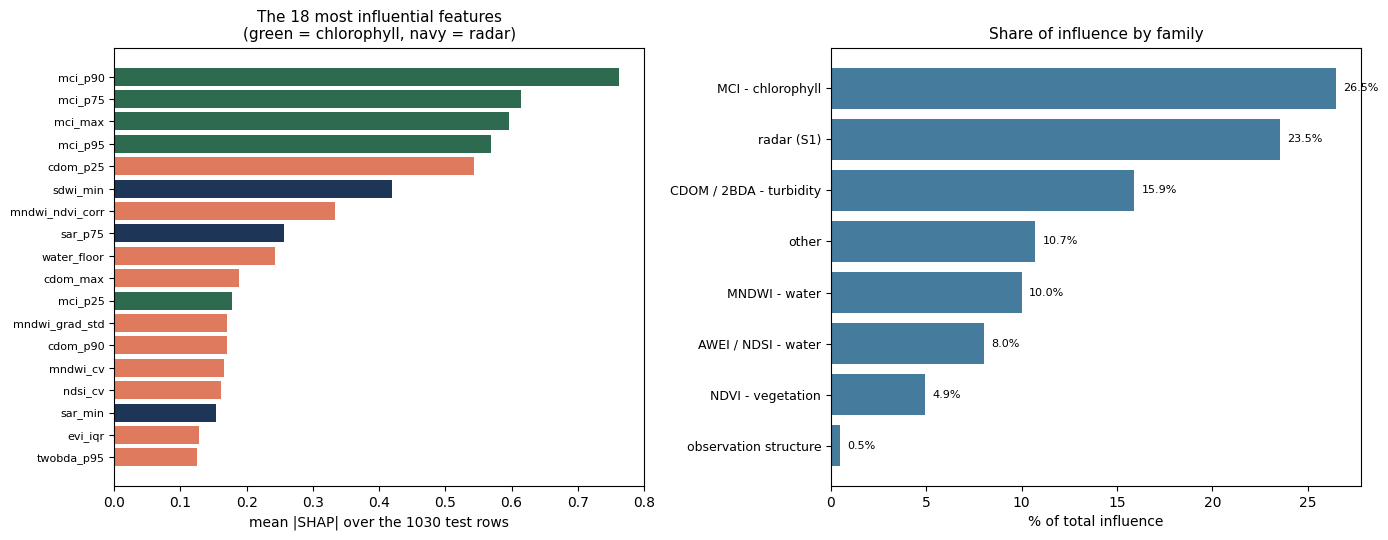

water QUALITY  (chlorophyll + turbidity) :  42.3 %
water PRESENCE (MNDWI + AWEI/NDSI)       :  18.0 %
observation structure                    :   0.5 %


In [16]:
def family(k):
    if k.startswith('mci'):                             return 'MCI - chlorophyll'
    if k.startswith('mndwi'):                           return 'MNDWI - water'
    if k.split('_')[0] in ('sar', 'sdwi', 'rvi', 'vh'): return 'radar (S1)'
    if k.startswith(('awei', 'ndsi')):                  return 'AWEI / NDSI - water'
    if k.startswith('ndvi'):                            return 'NDVI - vegetation'
    if k.startswith(('cdom', 'twobda')):                return 'CDOM / 2BDA - turbidity'
    if k.startswith(('n_', 'first_', 'last_', 'block_', 'obs_')): return 'observation structure'
    return 'other'

fam = imp.groupby(imp.index.map(family)).sum().sort_values(ascending=False)
fam_pct = 100 * fam / fam.sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
top = imp.head(18)[::-1]
cols_bar = ['#2d6a4f' if f == 'MCI - chlorophyll' else
            '#1d3557' if f == 'radar (S1)' else '#e07a5f' for f in top.index.map(family)]
ax[0].barh(range(len(top)), top.values, color=cols_bar)
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels(top.index, fontsize=8)
ax[0].set_xlabel('mean |SHAP| over the 1030 test rows')
ax[0].set_title('The 18 most influential features\n(green = chlorophyll, navy = radar)', fontsize=11)

ax[1].barh(range(len(fam_pct))[::-1], fam_pct.values, color='#457b9d')
ax[1].set_yticks(range(len(fam_pct))[::-1]); ax[1].set_yticklabels(fam_pct.index, fontsize=9)
ax[1].set_xlabel('% of total influence'); ax[1].set_title('Share of influence by family', fontsize=11)
for i, v in enumerate(fam_pct.values):
    ax[1].text(v + .4, len(fam_pct) - 1 - i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

water_quality = fam_pct.get('MCI - chlorophyll', 0) + fam_pct.get('CDOM / 2BDA - turbidity', 0)
water_presence = fam_pct.get('MNDWI - water', 0) + fam_pct.get('AWEI / NDSI - water', 0)
print(f'water QUALITY  (chlorophyll + turbidity) : {water_quality:5.1f} %')
print(f'water PRESENCE (MNDWI + AWEI/NDSI)       : {water_presence:5.1f} %')
print(f'observation structure                    : {fam_pct.get("observation structure", 0):5.1f} %')

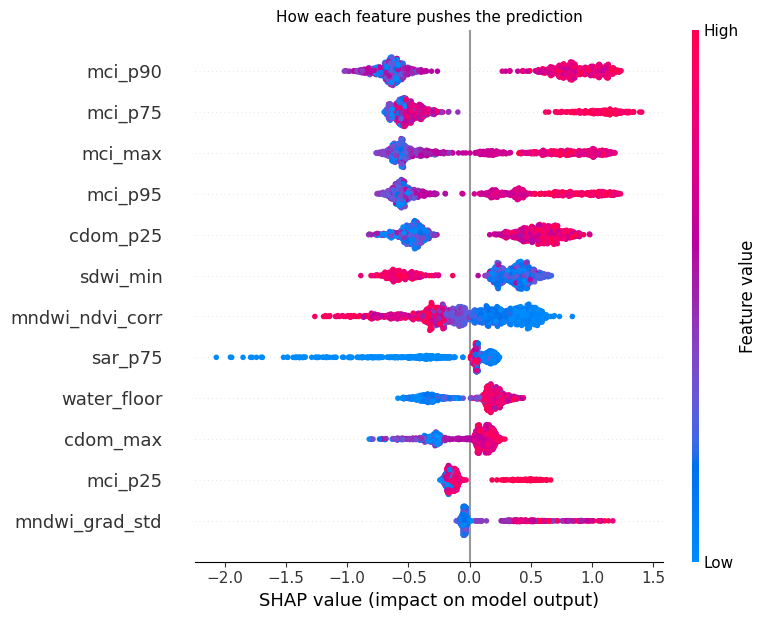

In [17]:
shap.summary_plot(sv, Xt_shap[cols_shap], max_display=12, show=False)
plt.title('How each feature pushes the prediction', fontsize=11)
plt.tight_layout(); plt.show()

### What SHAP says

**The model is not a water detector.** The four most influential features are all
MCI percentiles — a red-edge **chlorophyll** index — and water quality
(chlorophyll + turbidity) carries more than twice the influence of water presence
(MNDWI + AWEI/NDSI). The model has learned to ask *what kind of water*, not
*whether there is water*: aquaculture ponds are fed and fertilised, hence
eutrophic, and that separates them from clear natural lakes far better than any
water index. Section 2 saw the same thing in a single univariate AUC, before any
model existed.

**Radar earns its keep**, at just under a quarter of the total influence. That
retrospectively justifies the decoupled sensor masks: the 320 radar-only cells
feed a signal the model genuinely uses.

**The observation structure carries 0.5 %.** Those features describe the sampling
process — how many months were seen, which ones, how long the window is — rather
than the ground. The model is not exploiting the acquisition artefact, which is
the reassuring answer to an obvious worry about the masking simulation.

**And it explains the failure mode.** The remaining errors are concentrated on
**drained ponds**, real ponds whose observed window catches them empty. A drained
pond has neither water nor chlorophyll, so the model's principal evidence is
simply absent. That is why the deficit is recall, and why it resisted eight
separate attempts to fix it.

---

## 10. Result

| | public (~309 rows) | private (721 rows) |
|---|---|---|
| `submission_v9_pl_r3.csv` | 0.942367202 | **0.947 — 9th place** |

Public decomposition: **AUC 0.969432, F1 0.924324**, 580 positives of 1 030. The
private score landed *above* the public one, which is what a solution built to
generalise rather than to fit the public split should do.


**Cost.** 3 h 15 min measured on an Intel i5-8365U laptop CPU, 0.081 kWh measured
with CodeCarbon.